# BiLSTM with GloVe Embeddings for Ticket Type Classification

This notebook implements a Bidirectional Long Short-Term Memory (BiLSTM) neural network for automatic ticket type classification.

The model uses:

- Combined Ticket Subject and Ticket Description text
- Pre-trained GloVe word embeddings (100 dimensions)
- Bidirectional LSTM architecture
- Batch Normalization
- Dropout Regularization

The objective is to determine whether deep learning methods can improve classification performance compared to traditional machine learning models such as Logistic Regression, Random Forest, XGBoost, and LightGBM.

Evaluation Metrics:

- Accuracy
- F1-Score (Macro)

Experiment tracking is performed using MLflow and DagsHub.

In [ ]:
import pandas as pd
import numpy as np
import joblib
from pathlib import Path

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import (
    Embedding,
    Bidirectional,
    LSTM,
    Dense,
    Dropout,
    BatchNormalization
)

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau
)

from sklearn.preprocessing import LabelEncoder

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report
)

import tensorflow as tf

import mlflow
import dagshub

In [4]:
# Load Datasets
X_train = pd.read_parquet(
    '../data/processed/ticket_type/X_train.parquet'
)

X_val = pd.read_parquet(
    '../data/processed/ticket_type/X_val.parquet'
)

X_test = pd.read_parquet(
    '../data/processed/ticket_type/X_test.parquet'
)

y_train = pd.read_parquet(
    '../data/processed/ticket_type/y_train.parquet'
).squeeze()

y_val = pd.read_parquet(
    '../data/processed/ticket_type/y_val.parquet'
).squeeze()

y_test = pd.read_parquet(
    '../data/processed/ticket_type/y_test.parquet'
).squeeze()

## Text Extraction

For the BiLSTM model, only the processed ticket description is used as input text, as specified in the project requirements.

The processed descriptions are extracted from the train, validation, and test datasets and will be converted into token sequences for deep learning model training.

In [5]:
# taking ticket description only for biLSTM

X_train_text = X_train['processed_description']
X_val_text = X_val['processed_description']
X_test_text = X_test['processed_description']

## Label Encoding

The target labels are converted into numerical form for neural network training.

A LabelEncoder is used to transform ticket categories into integer labels.

In [6]:
# Encode labels

label_encoder = LabelEncoder()

y_train_enc = label_encoder.fit_transform(y_train)
y_val_enc = label_encoder.transform(y_val)
y_test_enc = label_encoder.transform(y_test)

print(label_encoder.classes_)
print("Number of classes:", len(label_encoder.classes_))

['Billing inquiry' 'Cancellation request' 'Product inquiry'
 'Refund request' 'Technical issue']
Number of classes: 5


## Text Tokenization

The ticket descriptions are converted into sequences of integer tokens using the Keras Tokenizer.

Only the most frequent words are retained to reduce vocabulary size and computational complexity.

In [7]:
# Tokenize
MAX_WORDS = 10000

tokenizer = Tokenizer(
    num_words=MAX_WORDS,
    oov_token="<OOV>"
)

tokenizer.fit_on_texts(X_train_text)

In [14]:
# save tokenizer

Path('../models/deep_learning').mkdir(
    parents=True,
    exist_ok=True
)

joblib.dump(
    tokenizer,
    '../models/deep_learning/bilstm_tokenizer.pkl'
)

['../models/deep_learning/bilstm_tokenizer.pkl']

In [8]:
# create sequence
X_train_seq = tokenizer.texts_to_sequences(X_train_text)
X_val_seq = tokenizer.texts_to_sequences(X_val_text)
X_test_seq = tokenizer.texts_to_sequences(X_test_text)

In [9]:
# check sequence lengths
seq_lengths = [len(seq) for seq in X_train_seq]

print("Max Length:", max(seq_lengths))
print("Average Length:", np.mean(seq_lengths))
print("95th Percentile:", np.percentile(seq_lengths, 95))

Max Length: 45
Average Length: 20.87365047233468
95th Percentile: 27.0


## Sequence Padding

To ensure a fixed input size for the BiLSTM model, token sequences are padded to a uniform length.

Based on the sequence length analysis, a maximum sequence length of 30 tokens is selected, covering approximately 95% of the training samples.

In [10]:
MAX_SEQUENCE_LENGTH = 30

In [15]:
# Pad sequences

X_train_pad = pad_sequences(
    X_train_seq,
    maxlen=MAX_SEQUENCE_LENGTH,
    padding='post',
    truncating='post'
)

X_val_pad = pad_sequences(
    X_val_seq,
    maxlen=MAX_SEQUENCE_LENGTH,
    padding='post',
    truncating='post'
)

X_test_pad = pad_sequences(
    X_test_seq,
    maxlen=MAX_SEQUENCE_LENGTH,
    padding='post',
    truncating='post'
)

print(X_train_pad.shape)
print(X_val_pad.shape)
print(X_test_pad.shape)

(5928, 30)
(1270, 30)
(1271, 30)


## GloVe Embeddings

Pre-trained GloVe (Global Vectors for Word Representation) embeddings are used to initialize the embedding layer of the BiLSTM model.

The 100-dimensional GloVe vectors capture semantic relationships between words and provide richer representations than randomly initialized embeddings.

In [16]:
## Load Pre-trained GloVe Embeddings

EMBEDDING_DIM = 100

embeddings_index = {}

with open(
    '../embeddings/glove.6B.100d.txt',
    encoding='utf-8'
) as f:

    for line in f:
        values = line.split()

        word = values[0]

        coefs = np.asarray(
            values[1:],
            dtype='float32'
        )

        embeddings_index[word] = coefs

print(
    f"Loaded {len(embeddings_index)} word vectors."
)

Loaded 400000 word vectors.


In [17]:
# Create Embedding Matrix

word_index = tokenizer.word_index

num_words = min(
    MAX_WORDS,
    len(word_index) + 1
)

embedding_matrix = np.zeros(
    (num_words, EMBEDDING_DIM)
)

for word, i in word_index.items():

    if i >= MAX_WORDS:
        continue

    embedding_vector = embeddings_index.get(word)

    if embedding_vector is not None:
        embedding_matrix[i] = embedding_vector

print("Embedding Matrix Shape:")
print(embedding_matrix.shape)

Embedding Matrix Shape:
(5673, 100)


In [18]:
# Check Vocabulary Coverage
hits = 0
misses = 0

for word, i in word_index.items():

    if i >= MAX_WORDS:
        continue

    if embeddings_index.get(word) is not None:
        hits += 1
    else:
        misses += 1

print("Words Found:", hits)
print("Words Missing:", misses)

coverage = hits / (hits + misses)

print(f"Coverage: {coverage:.2%}")

Words Found: 4211
Words Missing: 1461
Coverage: 74.24%


## BiLSTM Architecture

A Bidirectional Long Short-Term Memory (BiLSTM) network is used to capture contextual information from both forward and backward directions of the ticket description text.

The embedding layer is initialized using pre-trained GloVe embeddings. Batch Normalization and Dropout are applied to improve training stability and reduce overfitting.

In [19]:
# Build BiLSTM Model

NUM_CLASSES = len(label_encoder.classes_)

bilstm_model = Sequential([

    Embedding(
        input_dim=num_words,
        output_dim=EMBEDDING_DIM,
        weights=[embedding_matrix],
        input_length=MAX_SEQUENCE_LENGTH,
        trainable=False
    ),

    Bidirectional(
        LSTM(
            64,
            return_sequences=False
        )
    ),

    BatchNormalization(),

    Dropout(0.3),

    Dense(
        64,
        activation='relu'
    ),

    Dropout(0.3),

    Dense(
        NUM_CLASSES,
        activation='softmax'
    )
])

bilstm_model.summary()

c:\Users\abdul\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\core\embedding.py:103: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │       567,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 567,300 (2.16 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 567,300 (2.16 MB)

In [20]:
# Compile Model
bilstm_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [21]:
# Configure training callbacks

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=2,
    verbose=1
)

## Model Training

The BiLSTM model is trained using the padded ticket descriptions and evaluated on the validation dataset.

Early stopping and learning rate reduction are used to improve convergence and prevent overfitting.

In [22]:
# Train Model
history = bilstm_model.fit(
    X_train_pad,
    y_train_enc,
    validation_data=(
        X_val_pad,
        y_val_enc
    ),
    epochs=15,
    batch_size=32,
    callbacks=[
        early_stop,
        reduce_lr
    ],
    verbose=1
)

Epoch 1/15
186/186 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - accuracy: 0.1974 - loss: 1.8283 - val_accuracy: 0.2055 - val_loss: 1.6096 - learning_rate: 0.0010
Epoch 2/15
186/186 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.2048 - loss: 1.6829 - val_accuracy: 0.2016 - val_loss: 1.6090 - learning_rate: 0.0010
Epoch 3/15
186/186 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.2137 - loss: 1.6391 - val_accuracy: 0.2079 - val_loss: 1.6135 - learning_rate: 0.0010
Epoch 4/15
181/186 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.2124 - loss: 1.6261
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
186/186 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.2193 - loss: 1.6214 - val_accuracy: 0.2087 - val_loss: 1.6145 - learning_rate: 0.0010
Epoch 5/15
186/186 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.2235 - loss: 1.6167 - val_accuracy: 0.2024 - val_loss: 1.6098 - learning_rate: 5.0000e-04


In [23]:
# Evaluate
y_val_prob = bilstm_model.predict(
    X_val_pad
)

y_val_pred = np.argmax(
    y_val_prob,
    axis=1
)

40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step


In [24]:
# Metrics

bilstm_accuracy = accuracy_score(
    y_val_enc,
    y_val_pred
)

bilstm_f1 = f1_score(
    y_val_enc,
    y_val_pred,
    average='macro'
)

print(f"Accuracy: {bilstm_accuracy:.4f}")
print(f"F1-Macro: {bilstm_f1:.4f}")

Accuracy: 0.2016
F1-Macro: 0.1742


In [25]:
# Classification Report
print(
    classification_report(
        y_val_enc,
        y_val_pred,
        target_names=label_encoder.classes_
    )
)

                      precision    recall  f1-score   support

     Billing inquiry       0.20      0.43      0.28       245
Cancellation request       0.22      0.11      0.14       254
     Product inquiry       0.25      0.03      0.06       246
      Refund request       0.20      0.31      0.24       263
     Technical issue       0.19      0.13      0.15       262

            accuracy                           0.20      1270
           macro avg       0.21      0.20      0.17      1270
        weighted avg       0.21      0.20      0.17      1270



## BiLSTM Results

The BiLSTM model was trained using pre-trained GloVe embeddings and ticket description text.

### Validation Performance

- Accuracy: 20.16%
- F1-Macro: 17.42%

### Observations

- The BiLSTM model did not outperform the best classical machine learning models.
- Performance remained close to the random baseline for a five-class classification problem.
- The model struggled to distinguish between ticket categories despite the use of pre-trained word embeddings.
- Results suggest that the available ticket descriptions contain limited discriminative information for the target classes.

### Comparison with Classical Models

Logistic Regression and XGBoost achieved higher Accuracy and F1-Macro scores than the BiLSTM model, indicating that increasing model complexity did not improve classification performance on the current dataset.

In [26]:
# Save Models

Path('../models/deep_learning').mkdir(
    parents=True,
    exist_ok=True
)

bilstm_model.save(
    '../models/deep_learning/bilstm_glove.keras'
)

In [29]:
# Save Results

bilstm_results = pd.DataFrame({
    'Model': ['BiLSTM_GloVe'],
    'Accuracy': [bilstm_accuracy],
    'F1_Macro': [bilstm_f1]
})

bilstm_results.to_csv("../model_results/bilstm_results.csv", index=False)

# MLflow Logging BiLSTM

https://dagshub.com/armaaz.au.stats/AI-Powered-Customer-Support-Intelligence-Platform.git

In [30]:
dagshub.init(
    repo_owner='armaaz.au.stats',
    repo_name='AI-Powered-Customer-Support-Intelligence-Platform',
    mlflow=True
)

Accessing as armaaz.au.stats

Initialized MLflow to track repo "armaaz.au.stats/AI-Powered-Customer-Support-Intelligence-Platform"

Repository armaaz.au.stats/AI-Powered-Customer-Support-Intelligence-Platform initialized!

In [31]:
# Set experiment
mlflow.set_experiment(
    "BiLSTM Model"
)

2026/06/11 00:10:30 INFO mlflow.tracking.fluent: Experiment with name 'BiLSTM Model' does not exist. Creating a new experiment.


<Experiment: artifact_location='mlflow-artifacts:/ee4d258350fe42d5988d5e86607bfb8f', creation_time=1781116830470, effective_trace_archival_retention=None, experiment_id='2', last_update_time=1781116830470, lifecycle_stage='active', name='BiLSTM Model', tags={}, trace_location=None, workspace='default'>

In [32]:
# Log model
with mlflow.start_run(run_name="BiLSTM_GloVe"):

    mlflow.log_param(
        "embedding",
        "GloVe_100d"
    )

    mlflow.log_param(
        "lstm_units",
        64
    )

    mlflow.log_param(
        "max_sequence_length",
        30
    )

    mlflow.log_metric(
        "val_accuracy",
        bilstm_accuracy
    )

    mlflow.log_metric(
        "val_f1_macro",
        bilstm_f1
    )

    mlflow.tensorflow.log_model(
        bilstm_model,
        name="model"
    )

2026/06/11 00:10:40 WARNING mlflow.tensorflow: You are saving a TensorFlow Core model or Keras model without a signature. Inference with mlflow.pyfunc.spark_udf() will not work unless the model's pyfunc representation accepts pandas DataFrames as inference inputs.


🏃 View run BiLSTM_GloVe at: https://dagshub.com/armaaz.au.stats/AI-Powered-Customer-Support-Intelligence-Platform.mlflow/#/experiments/2/runs/8033edeb43e54a8194e3b6a7564380c7
🧪 View experiment at: https://dagshub.com/armaaz.au.stats/AI-Powered-Customer-Support-Intelligence-Platform.mlflow/#/experiments/2


## Overall Model Comparison

The performance of the BiLSTM model is compared against all previously developed machine learning models for Ticket Type Classification.

This comparison provides a consolidated benchmark before proceeding to Transformer-based approaches.

In [33]:
all_model_results = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Multinomial Naive Bayes',
        'Random Forest',
        'XGBoost',
        'LightGBM',
        'BiLSTM + GloVe'
    ],
    'Accuracy': [
        0.2087,
        0.2071,
        0.2008,
        0.2079,
        0.1882,
        bilstm_accuracy
    ],
    'F1_Macro': [
        0.2078,
        0.2045,
        0.1886,
        0.2062,
        0.1881,
        bilstm_f1
    ]
})

all_model_results = all_model_results.sort_values(
    by='F1_Macro',
    ascending=False
)

all_model_results

,Model,Accuracy,F1_Macro
0,Logistic Regression,0.208700,0.207800
3,XGBoost,0.207900,0.206200
1,Multinomial Naive Bayes,0.207100,0.204500
2,Random Forest,0.200800,0.188600
4,LightGBM,0.188200,0.188100
5,BiLSTM + GloVe,0.201575,0.174215


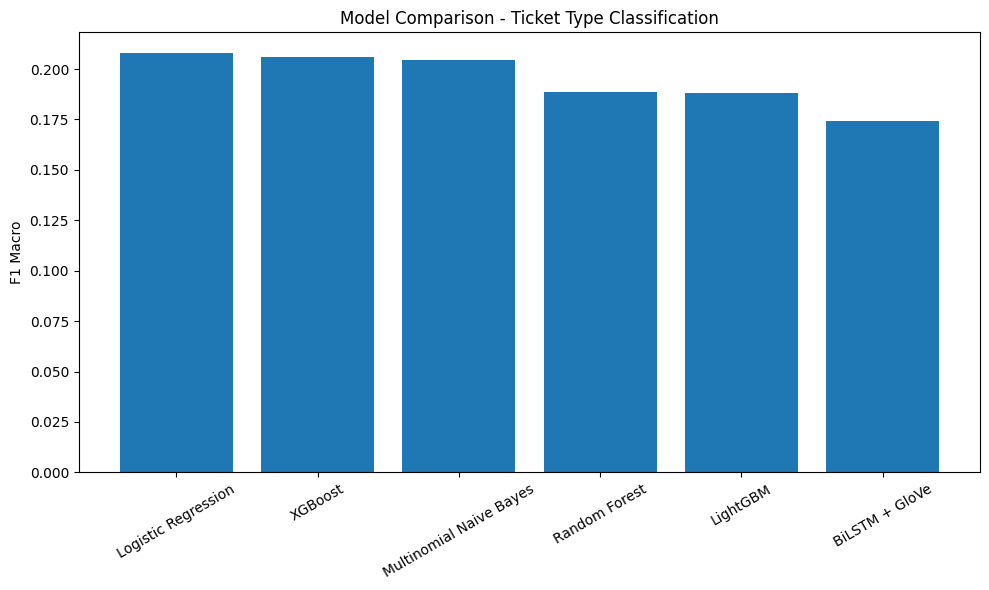

In [34]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.bar(
    all_model_results['Model'],
    all_model_results['F1_Macro']
)

plt.xticks(rotation=30)
plt.ylabel('F1 Macro')
plt.title('Model Comparison - Ticket Type Classification')

plt.tight_layout()
plt.show()

In [35]:
# save
all_model_results.to_csv(
    '../model_results/model_comparison_results.csv',
    index=False
)

## Conclusion

Six different approaches were evaluated for Ticket Type Classification:

1. Logistic Regression
2. Multinomial Naive Bayes
3. Random Forest
4. XGBoost
5. LightGBM
6. BiLSTM with GloVe Embeddings

### Key Findings

- Logistic Regression achieved the best overall performance.
- XGBoost produced comparable results but did not outperform Logistic Regression.
- The BiLSTM model did not improve performance despite using pre-trained GloVe embeddings.
- Increasing model complexity did not result in meaningful gains.
- The dataset appears to contain limited discriminative information for accurate ticket type prediction.

### Best Performing Model

Logistic Regression achieved the highest F1-Macro score and remains the strongest model among all evaluated approaches.

### Next Step

The final stage of the project will investigate Transformer-based language models through DistilBERT fine-tuning using the combined Ticket Subject and Ticket Description text.